# Project 2 — Risk structure after COVID-19

## 1. Setup

In [ ]:
import warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns, scipy.stats as scstats
import statsmodels.api as sm
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.stats.diagnostic import breaks_cusumolsresid

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")

COVID_BREAK_DATE = pd.Timestamp("2020-03-01")
ROLLING_WINDOW_DAYS = 60
HAC_LAGS = 6

## 2. Data loading

In [ ]:
ProjectRoot = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data" / "Data.xlsx").exists())
RawDataFrame = pd.read_excel(ProjectRoot / "data" / "Data.xlsx", sheet_name="Feuil1")
RawDataFrame = RawDataFrame.rename(columns={"Unnamed: 0": "Date"})
RawDataFrame["Date"] = pd.to_datetime(RawDataFrame["Date"])
RawDataFrame = RawDataFrame.sort_values("Date").set_index("Date")

COLUMN_RENAME = {"S&P500":"SP500", "Eurostoxx 50":"EuroStoxx50", "Hang Seng":"HangSeng",
                 "MSCI EM":"MSCIEm", "SMI":"SMI", "US T 10-year Yield":"US10Y",
                 "German Gov 10-year yield":"DE10Y", "Oil futures":"Oil", "Gold":"Gold",
                 "EURUSD":"EURUSD", "USDJPY":"USDJPY", "US IG Bonds":"USIG",
                 "US HY Bonds":"USHY", "USDCHF":"USDCHF"}
PriceDataFrame = RawDataFrame.rename(columns=COLUMN_RENAME).ffill(limit=2)
PriceDataFrame.tail(3)

,SP500,EuroStoxx50,HangSeng,MSCIEm,SMI,US10Y,DE10Y,Oil,Gold,EURUSD,USDJPY,USIG,USHY,USDCHF
Date,,,,,,,,,,,,,,
2026-04-22,7137.8999,5906.2202,26163.2402,1607.0699,13067.6299,4.3025,3.0084,92.9600,4739.8999,1.1705,159.4800,3613.8870,2696.9160,0.7847
2026-04-23,7108.3999,5894.7300,25915.1992,1599.3101,13248.0596,4.3244,3.0090,95.8500,4694.1401,1.1683,159.7100,3608.3889,2694.0430,0.7864
2026-04-24,7165.0801,5883.4800,25978.0703,1610.0000,13169.7002,4.3007,2.9937,94.4000,4709.5000,1.1722,159.3800,3612.0129,2695.6079,0.7850


## 3. Daily transformations

In [ ]:
PRICE_SERIES = ["SP500","EuroStoxx50","HangSeng","MSCIEm","SMI",
                "Oil","Gold","EURUSD","USDJPY","USDCHF","USIG","USHY"]
YIELD_SERIES = ["US10Y","DE10Y"]

DailyLogReturns = np.log(PriceDataFrame[PRICE_SERIES]).diff()
DailyYieldDiffs = PriceDataFrame[YIELD_SERIES].diff()
DailyReturnsAllAssets = pd.concat([DailyLogReturns, DailyYieldDiffs], axis=1).dropna(how="all")
DailyCreditReturnSpread = DailyLogReturns["USHY"] - DailyLogReturns["USIG"]
DailyTransatlanticYieldSpread = PriceDataFrame["US10Y"] - PriceDataFrame["DE10Y"]

## 4. Three monthly risk measures

In [ ]:
EquityComposite = DailyLogReturns[["SP500","EuroStoxx50","HangSeng","MSCIEm","SMI"]].mean(axis=1)
MonthlyEquityRealizedVol = np.sqrt((EquityComposite ** 2).resample("BME").sum())
MonthlyEquityRealizedVol.name = "sigma_eq"

def compute_rolling_measures(daily_returns_frame, window_days):
    MonthEnds = pd.date_range(daily_returns_frame.index.min(), daily_returns_frame.index.max(), freq="BME")
    records = []
    for me in MonthEnds:
        avail = daily_returns_frame.index[daily_returns_frame.index <= me]
        if len(avail) == 0: continue
        pos = daily_returns_frame.index.get_loc(avail[-1])
        if pos + 1 < window_days: continue
        Window = daily_returns_frame.iloc[pos + 1 - window_days : pos + 1].dropna()
        if len(Window) < int(0.8 * window_days): continue
        C = Window.corr().values
        rho_bar = C[np.triu_indices(C.shape[0], k=1)].mean()
        Standardized = (Window - Window.mean()) / Window.std(ddof=1)
        eigvals = np.sort(np.linalg.eigvalsh(np.cov(Standardized.values, rowvar=False)))[::-1]
        lambda_1 = eigvals[0] / eigvals.sum()
        records.append({"Date": me, "rho_bar": rho_bar, "lambda_1": lambda_1})
    return pd.DataFrame.from_records(records).set_index("Date")

MonthlyRollingMeasures = compute_rolling_measures(DailyReturnsAllAssets, ROLLING_WINDOW_DAYS)

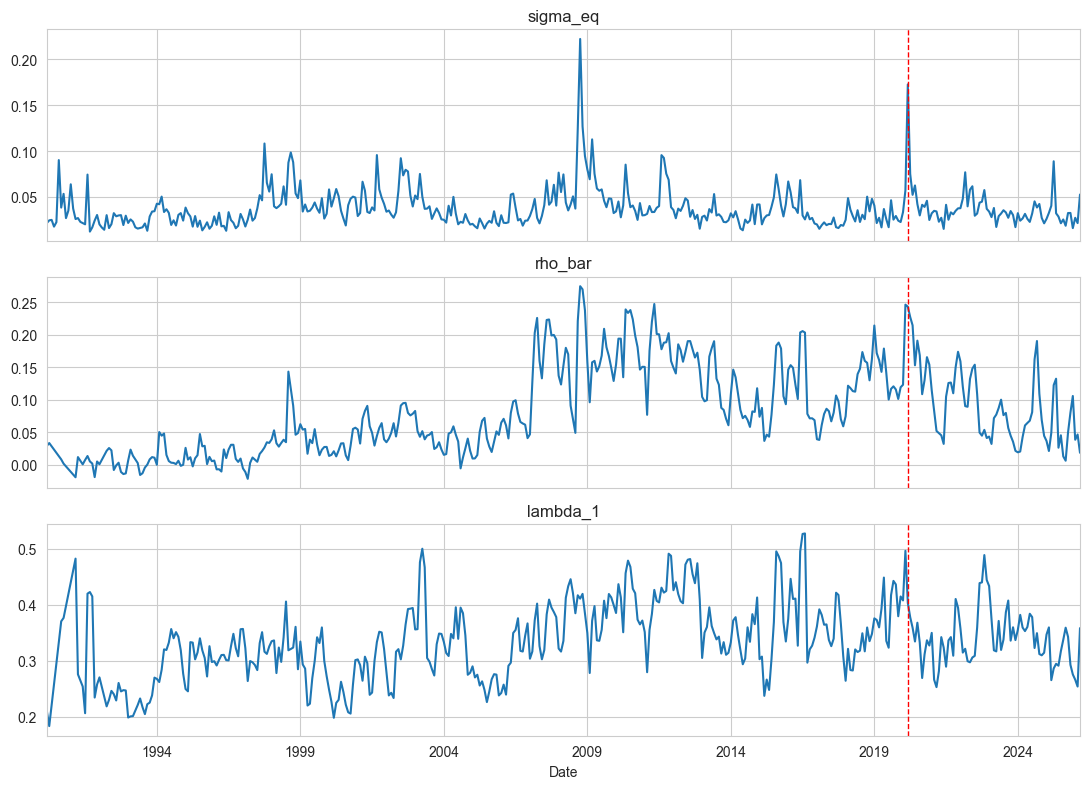

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
for ax, series in zip(axes, [MonthlyEquityRealizedVol,
                              MonthlyRollingMeasures["rho_bar"],
                              MonthlyRollingMeasures["lambda_1"]]):
    series.plot(ax=ax)
    ax.axvline(COVID_BREAK_DATE, color="red", linestyle="--", lw=1)
    ax.set_title(series.name)
plt.tight_layout(); plt.show()

## 5. Monthly panel with controls, lags and dummies

In [ ]:
def monthly_realized_vol(s): return np.sqrt((s ** 2).resample("BME").sum())

MonthlyControls = pd.DataFrame({
    "sigma_oil":    monthly_realized_vol(DailyLogReturns["Oil"]),
    "sigma_gold":   monthly_realized_vol(DailyLogReturns["Gold"]),
    "sigma_em":     monthly_realized_vol(DailyLogReturns["MSCIEm"]),
    "sigma_hs":     monthly_realized_vol(DailyLogReturns["HangSeng"]),
    "sigma_usdjpy": monthly_realized_vol(DailyLogReturns["USDJPY"]),
    "sigma_eurusd": monthly_realized_vol(DailyLogReturns["EURUSD"]),
    "abs_usdchf":   DailyLogReturns["USDCHF"].abs().resample("BME").mean(),
    "CRS":          DailyCreditReturnSpread.resample("BME").sum(),
    "TAS":          DailyTransatlanticYieldSpread.resample("BME").last(),
    "Delta_US10Y":  PriceDataFrame["US10Y"].resample("BME").last().diff(),
})

MonthlyDataFrame = pd.concat([MonthlyRollingMeasures, MonthlyEquityRealizedVol, MonthlyControls], axis=1)
MonthlyDataFrame = MonthlyDataFrame.dropna(subset=["rho_bar", "sigma_eq"])
MonthlyDataFrame["D_post"] = (MonthlyDataFrame.index >= COVID_BREAK_DATE).astype(int)

LAG_COLS = ["sigma_eq","sigma_oil","sigma_gold","sigma_em","sigma_hs",
            "sigma_usdjpy","sigma_eurusd","abs_usdchf","CRS","TAS","Delta_US10Y","rho_bar"]
for c in LAG_COLS:
    MonthlyDataFrame[c + "_lag1"] = MonthlyDataFrame[c].shift(1)

MonthlyDataFrame["sigma_eq_lag1_x_D_post"] = MonthlyDataFrame["sigma_eq_lag1"] * MonthlyDataFrame["D_post"]

MonthlyDataFrameForRegression = MonthlyDataFrame.dropna(subset=["sigma_eq_lag1"]).copy()
print(f"{MonthlyDataFrameForRegression.shape[0]} months "
      f"({(MonthlyDataFrameForRegression['D_post']==0).sum()} pre, "
      f"{(MonthlyDataFrameForRegression['D_post']==1).sum()} post)")

420 months (347 pre, 73 post)


## 6. Descriptive tests

In [ ]:
PreMask  = MonthlyDataFrameForRegression.index <  COVID_BREAK_DATE
PostMask = MonthlyDataFrameForRegression.index >= COVID_BREAK_DATE
rows = []
for s in ["sigma_eq","rho_bar","lambda_1"]:
    a = MonthlyDataFrameForRegression.loc[PreMask, s].dropna()
    b = MonthlyDataFrameForRegression.loc[PostMask, s].dropna()
    t, tp = scstats.ttest_ind(a, b, equal_var=False)
    L, lp = scstats.levene(a, b, center="median")
    rows.append({"series": s, "pre_mean": a.mean(), "post_mean": b.mean(),
                 "pre_std": a.std(ddof=1), "post_std": b.std(ddof=1),
                 "t_pvalue": tp, "levene_pvalue": lp})
pd.DataFrame(rows).set_index("series")

,pre_mean,post_mean,pre_std,post_std,t_pvalue,levene_pvalue
series,,,,,,
sigma_eq,0.0378,0.0376,0.0216,0.0212,0.9368,0.2598
rho_bar,0.0813,0.0900,0.0694,0.0561,0.2518,0.0420
lambda_1,0.3351,0.3399,0.0696,0.0475,0.4744,0.0003


## 7. Chow and CUSUM on rho_bar ~ sigma_eq_lag1

In [ ]:
YBase = MonthlyDataFrameForRegression["rho_bar"]
XBase = sm.add_constant(MonthlyDataFrameForRegression[["sigma_eq_lag1"]])

def chow_test(y, X, break_date):
    n, k = len(y), X.shape[1]
    pre, post = y.index < break_date, y.index >= break_date
    rss_full  = (sm.OLS(y, X).fit().resid ** 2).sum()
    rss_split = (sm.OLS(y[pre], X[pre]).fit().resid ** 2).sum() + (sm.OLS(y[post], X[post]).fit().resid ** 2).sum()
    F = ((rss_full - rss_split) / k) / (rss_split / (n - 2*k))
    return F, 1 - scstats.f.cdf(F, k, n - 2*k)

F_chow, p_chow = chow_test(YBase, XBase, COVID_BREAK_DATE)
BaselineResiduals = sm.OLS(YBase, XBase).fit().resid
cusum_stat, p_cusum, _ = breaks_cusumolsresid(BaselineResiduals, ddof=XBase.shape[1])
print(f"Chow  : F = {F_chow:.3f}, p = {p_chow:.3f}")
print(f"CUSUM : stat = {cusum_stat:.3f}, p = {p_cusum:.4f}")

Chow  : F = 0.784, p = 0.457
CUSUM : stat = 7.357, p = 0.0000


## 8. Models A, B, C, D, E, F (OLS with HAC, 6 lags)

In [ ]:
FittedModels = {}
def fit_hac(name, y_col, x_cols, df=None):
    df = MonthlyDataFrameForRegression if df is None else df
    data = pd.concat([df[y_col], sm.add_constant(df[x_cols])], axis=1).dropna()
    X = data.drop(columns=[y_col])
    res = sm.OLS(data[y_col], X).fit(cov_type="HAC", cov_kwds={"maxlags": HAC_LAGS})
    FittedModels[name] = res
    return res

SPECS = {
    "A": ["sigma_eq_lag1"],
    "B": ["sigma_eq_lag1","sigma_oil_lag1","sigma_gold_lag1","sigma_em_lag1","sigma_hs_lag1"],
    "C": ["sigma_eq_lag1","CRS_lag1","TAS_lag1","Delta_US10Y_lag1"],
    "D": ["sigma_eq_lag1","sigma_usdjpy_lag1","sigma_eurusd_lag1","abs_usdchf_lag1"],
    "E": ["sigma_eq_lag1","sigma_em_lag1","CRS_lag1","abs_usdchf_lag1"],
    "F": ["sigma_eq_lag1","sigma_eq_lag1_x_D_post","D_post"],
}
for name, cols in SPECS.items():
    fit_hac(name, "rho_bar", cols)

### Model A

In [ ]:
print(FittedModels["A"].summary().tables[1])

                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.0338      0.009      3.683      0.000       0.016       0.052
sigma_eq_lag1     1.3009      0.177      7.346      0.000       0.954       1.648


### Model B

In [ ]:
print(FittedModels["B"].summary().tables[1])

                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0433      0.013      3.236      0.001       0.017       0.070
sigma_eq_lag1       1.8568      0.674      2.756      0.006       0.537       3.177
sigma_oil_lag1     -0.1111      0.089     -1.253      0.210      -0.285       0.063
sigma_gold_lag1     0.3524      0.243      1.447      0.148      -0.125       0.830
sigma_em_lag1       0.7151      0.483      1.481      0.139      -0.232       1.662
sigma_hs_lag1      -1.0747      0.216     -4.972      0.000      -1.498      -0.651


### Model C

In [ ]:
print(FittedModels["C"].summary().tables[1])

                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.0094      0.010      0.911      0.362      -0.011       0.030
sigma_eq_lag1        1.4770      0.187      7.897      0.000       1.110       1.844
CRS_lag1             0.3273      0.198      1.652      0.099      -0.061       0.716
TAS_lag1             0.0226      0.005      4.121      0.000       0.012       0.033
Delta_US10Y_lag1    -0.0323      0.012     -2.600      0.009      -0.057      -0.008


### Model D

In [ ]:
print(FittedModels["D"].summary().tables[1])

                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.0844      0.014      6.244      0.000       0.058       0.111
sigma_eq_lag1         1.8296      0.220      8.305      0.000       1.398       2.261
sigma_usdjpy_lag1    -0.8720      0.463     -1.885      0.059      -1.779       0.035
sigma_eurusd_lag1    -0.2550      0.797     -0.320      0.749      -1.816       1.306
abs_usdchf_lag1      -8.4734      3.710     -2.284      0.022     -15.745      -1.202


### Model E

In [ ]:
print(FittedModels["E"].summary().tables[1])

                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0702      0.014      5.003      0.000       0.043       0.098
sigma_eq_lag1       1.2620      0.452      2.795      0.005       0.377       2.147
sigma_em_lag1       0.3785      0.390      0.972      0.331      -0.385       1.142
CRS_lag1            0.0346      0.161      0.215      0.830      -0.281       0.350
abs_usdchf_lag1   -11.2224      2.912     -3.854      0.000     -16.930      -5.515


### Model F

In [ ]:
print(FittedModels["F"].summary().tables[1])
WaldJoint = FittedModels["F"].wald_test("(sigma_eq_lag1_x_D_post = 0), (D_post = 0)", scalar=True)
print(f"Joint Wald (beta_2 = gamma = 0): stat = {float(WaldJoint.statistic):.3f}, p = {float(WaldJoint.pvalue):.3f}")

                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0.0336      0.011      3.142      0.002       0.013       0.055
sigma_eq_lag1              1.2648      0.206      6.125      0.000       0.860       1.670
sigma_eq_lag1_x_D_post     0.2159      0.279      0.774      0.439      -0.331       0.763
D_post                     0.0006      0.017      0.038      0.969      -0.032       0.033
Joint Wald (beta_2 = gamma = 0): stat = 1.211, p = 0.546


### Comparison table - A to F

In [ ]:
def row(name):
    res = FittedModels[name]
    p, pv = res.params, res.pvalues
    return {
        "model": name,
        "adj_R2": res.rsquared_adj,
        "beta_1": p.get("sigma_eq_lag1", np.nan), "p_beta_1": pv.get("sigma_eq_lag1", np.nan),
        "beta_2": p.get("sigma_eq_lag1_x_D_post", np.nan),
        "p_beta_2": pv.get("sigma_eq_lag1_x_D_post", np.nan),
        "gamma":  p.get("D_post", np.nan),
        "p_gamma": pv.get("D_post", np.nan),
    }
pd.DataFrame([row(n) for n in ["A","B","C","D","E","F"]]).set_index("model")

,adj_R2,beta_1,p_beta_1,beta_2,p_beta_2,gamma,p_gamma
model,,,,,,,
A,0.1711,1.3009,0.0000,NaN,NaN,NaN,NaN
B,0.2874,1.8568,0.0058,NaN,NaN,NaN,NaN
C,0.2526,1.4770,0.0000,NaN,NaN,NaN,NaN
D,0.2614,1.8296,0.0000,NaN,NaN,NaN,NaN
E,0.2487,1.2620,0.0052,NaN,NaN,NaN,NaN
F,0.1702,1.2648,0.0000,0.2159,0.4392,0.0006,0.9694


## 9. Model F with Y = sigma_eq

In [ ]:
ModelF_on_sigma = fit_hac("F_on_sigma_eq", "sigma_eq",
                          ["sigma_eq_lag1","sigma_eq_lag1_x_D_post","D_post"])
print(ModelF_on_sigma.summary().tables[1])

                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0.0128      0.002      7.729      0.000       0.010       0.016
sigma_eq_lag1              0.6621      0.050     13.161      0.000       0.563       0.761
sigma_eq_lag1_x_D_post    -0.2769      0.074     -3.768      0.000      -0.421      -0.133
D_post                     0.0102      0.003      3.508      0.000       0.005       0.016


## 10. Model F with Y = lambda_1

In [ ]:
ModelF_on_lambda = fit_hac("F_on_lambda_1", "lambda_1",
                           ["sigma_eq_lag1","sigma_eq_lag1_x_D_post","D_post"])
print(ModelF_on_lambda.summary().tables[1])

                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0.2962      0.012     23.956      0.000       0.272       0.320
sigma_eq_lag1              1.0317      0.271      3.810      0.000       0.501       1.562
sigma_eq_lag1_x_D_post    -0.8165      0.347     -2.355      0.019      -1.496      -0.137
D_post                     0.0356      0.017      2.123      0.034       0.003       0.068


## 11. Model F_ARX 

In [ ]:
ModelF_ARX = fit_hac("F_ARX", "rho_bar",
                     ["rho_bar_lag1","sigma_eq_lag1","sigma_eq_lag1_x_D_post","D_post"])
print(ModelF_ARX.summary().tables[1])

                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0.0056      0.002      2.228      0.026       0.001       0.010
rho_bar_lag1               0.8864      0.021     42.248      0.000       0.845       0.927
sigma_eq_lag1              0.1120      0.064      1.741      0.082      -0.014       0.238
sigma_eq_lag1_x_D_post     0.0310      0.119      0.262      0.793      -0.201       0.263
D_post                    -0.0035      0.006     -0.560      0.576      -0.016       0.009


## 12. VAR(1) + Granger causality on (rho_bar, sigma_eq)

In [ ]:
VarData = MonthlyDataFrameForRegression[["rho_bar","sigma_eq"]].dropna()
LagSelection = VAR(VarData).select_order(maxlags=12)
ChosenLag = int(LagSelection.hqic) if LagSelection.hqic > 0 else 1
VarResults = VAR(VarData).fit(ChosenLag)
print(f"Lag chosen by HQ: {ChosenLag}")
print(VarResults.test_causality("rho_bar", "sigma_eq", kind="f"))
print(VarResults.test_causality("sigma_eq", "rho_bar", kind="f"))

Lag chosen by HQ: 4
<statsmodels.tsa.vector_ar.hypothesis_test_results.CausalityTestResults object. H_0: sigma_eq does not Granger-cause rho_bar: reject at 5% significance level. Test statistic: 4.891, critical value: 2.383>, p-value: 0.001>
<statsmodels.tsa.vector_ar.hypothesis_test_results.CausalityTestResults object. H_0: rho_bar does not Granger-cause sigma_eq: reject at 5% significance level. Test statistic: 4.136, critical value: 2.383>, p-value: 0.003>


## Résumé

#### sigma_eq : niveau de risque
**T-test pré vs post :** Moyenne inchangée  
**Levene :** Variance inchangée  
**Modèle F (Y=sigma):** Persistance plus faible après COVID et niveau de base plus haut   

Changement partiel  

#### rho_bar : co-mouvement
**T-tests :** Inchangé  
**Levene :** Légèrement différente  
**Chow sur Model A à mars 2020 :** Pas de rupture  
**CUSUM :** Instabilité globale mais pas concentrée à Mars 2020
**Modèle A :** Lien volatilité - corrélation existe  
**VAR + Granger :** Double causalité vol. - corr.  
**Modèle F :** B2 (post covid) non significatif  
**Modèle F ARX :** Lag1 explique ENORMEMENT rho_bar. Donc trop dur de détecter différence avant/après.

Pas de changement clair  

#### lambda_1 : concentration du risque
**T-tests :** Pas de changement  
**Levene :** Variance plus serrée post-Covid  
**Modele F (Y = lambda_1) :** Niveau plus haut post-Covid et sensibilité à la volatilité réduite  

Changement clair